# CA1


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## PART 1

In [3]:
img = cv.imread("Pic.jpg")
print(img.shape)
print(img.dtype)
print(type(img))

(633, 800, 3)
uint8
<class 'numpy.ndarray'>


In [4]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
_ , img_binary = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)

#cv.imshow("Original", img)
#cv.imshow("RGB Image", img_rgb)
#cv.imshow("Gray Image", img_gray)
#cv.imshow("Binary Image", img_binary)
#cv.waitKey(0)
#cv.destroyAllWindows()

cv.imwrite("Pics\original.jpg", img)
cv.imwrite("Pics\\RGB.jpg", img_rgb)
cv.imwrite("Pics\Gray.jpg", img_gray)
cv.imwrite("Pics\\binary.jpg", img_binary)

True

In [5]:
img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

#cv.imshow("HSV Image", img_hsv)
#cv.waitKey(0)
#cv.destroyAllWindows()

cv.imwrite("Pics\HSV.jpg", img_hsv)


True

In [6]:
all_img = [ img_rgb , img_hsv ]
for i in range(0,len(all_img)):
    temp_img = all_img[i]
    v1, v2, v3 = cv.split(temp_img)
    Name = "RGB" if i == 0 else "HSV"
    cv.imwrite(f"Pics\First component {Name}.jpg", v1)
    cv.imwrite(f"Pics\Second component {Name}.jpg", v2)
    cv.imwrite(f"Pics\Third component {Name}.jpg", v3)
    #cv.imshow("First component", v1)
    #cv.imshow("Second component", v2)
    #cv.imshow("Third component", v3)
    #cv.waitKey(0)
    #cv.destroyAllWindows()


# with color
v1, v2, v3 = cv.split(img_rgb)
zeros = np.zeros_like(v1)
cv.imwrite("Pics\First component RGB (with color).jpg", cv.merge([v1, zeros, zeros]))
cv.imwrite("Pics\Second component RGB (with color).jpg", cv.merge([zeros, v2, zeros]))
cv.imwrite("Pics\Third component RGB (with color).jpg", cv.merge([zeros, zeros, v3]))



True

In [7]:
contrast = img_gray.std()
print("Original Contrast:", contrast)

higher_contrast_img = cv.convertScaleAbs(img, alpha=1.5, beta=0)
lower_contrast_img = cv.convertScaleAbs(img, alpha=0.2, beta=0)

## to calculate contrast
higher_contrast = cv.cvtColor(higher_contrast_img, cv.COLOR_BGR2GRAY)
lower_contrast = cv.cvtColor(lower_contrast_img, cv.COLOR_BGR2GRAY)

print("Higher Contrast:", higher_contrast.std())
print("Lower Contrast:", lower_contrast.std())

cv.imwrite("Pics\Higher Contrast.jpg", higher_contrast_img)
cv.imwrite("Pics\Lower Contrast.jpg", lower_contrast_img)


#cv.imshow("Original Image", img)
#cv.imshow("Higher Contrast", higher_contrast)
#cv.imshow("Lower Contrast", lower_contrast)
#cv.waitKey(0)
#cv.destroyAllWindows()


Original Contrast: 54.84205130125853
Higher Contrast: 62.31837678713477
Lower Contrast: 10.989012253508205


True

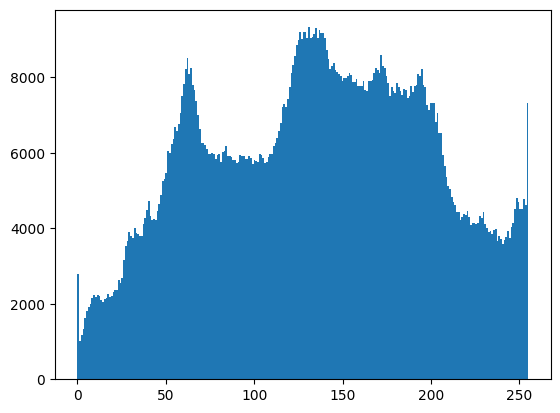

In [8]:
plt.hist(img.ravel(), 256, [0,255])
plt.show()

In [9]:
## Histogram Equalization
b, g, r = cv.split(img)

b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

img_equalized = cv.merge((b_eq, g_eq, r_eq))

cv.imwrite("Pics\img_equalized (with color).jpg", img_equalized)
cv.imwrite("Pics\img_equalized.jpg", cv.equalizeHist(img_gray))


## Histogram Stretching
def HistogramStretching(img):
    min_val = np.min(img)
    max_val = np.max(img)
    stretched = (img - min_val) / (max_val - min_val) * 255
    img_stretched = stretched.astype('uint8')
    return img_stretched

cv.imwrite("Pics\img_stretched(for img).jpg", HistogramStretching(img))
cv.imwrite("Pics\img_stretched(for lower_contrast_img).jpg", HistogramStretching(lower_contrast_img))

True

## PART 2

In [10]:
img = cv.imread("Pic.jpg")
noise = np.random.rand(*img.shape)
SaltPepper_img = img.copy()
SaltPepper_img[noise < 0.02] = 0
SaltPepper_img[noise > 0.98] = 255

cv.imwrite("Pics\salt_pepper.jpg", SaltPepper_img)


gaussian_noise = np.random.normal(0, 50, img.shape)
gaussian_noise_img = img + gaussian_noise
gaussian_noise_img = np.clip(gaussian_noise_img, 0, 255).astype('uint8')

cv.imwrite("Pics\gaussian_noise.jpg", gaussian_noise_img)

True

In [11]:
def apply_kernel(image, kernel):
    image = np.array(image, dtype=np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    h, w, c = image.shape
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded_image = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w), (0, 0)),
        mode='constant'
    )

    output = np.zeros((h, w, c), dtype=np.float32)

    for ch in range(c):
        for i in range(h):
            for j in range(w):
                region = padded_image[i:i+kh, j:j+kw, ch]
                output[i, j, ch] = np.sum(region * kernel)

    return output


def Median_Filter(image, kernel):
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    padded = np.pad(image, ((ph, ph), (pw, pw), (0,0)), mode='edge')
    output = np.zeros_like(image)
    H, W, C = image.shape

    mask = kernel == 1
    for i in range(H):
        for j in range(W):
            window = padded[i:i+kh, j:j+kw]
            vals = window[mask]
            output[i, j] = np.median(vals.reshape(-1, C), axis=0)
    return output

In [12]:
convolutional_kernel = (1/9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32)

convolutional_kernel_img = apply_kernel(SaltPepper_img, convolutional_kernel)
cv.imwrite("Pics\convolutional_kernel.jpg", convolutional_kernel_img)

median_kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

median_filtered_img = Median_Filter(SaltPepper_img, median_kernel)
cv.imwrite("Pics/median_kernel.jpg", median_filtered_img )

True

In [13]:
laplacian_kernel = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)
laplacian_result = apply_kernel(img, laplacian_kernel)
laplacian_display = np.clip(np.abs(laplacian_result), 0, 255).astype(np.uint8)
cv.imwrite("Pics\laplacian_kernel.jpg", laplacian_display)

sharpen_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

sharpen_result = apply_kernel(img, sharpen_kernel)
sharpen_display = np.clip(np.abs(sharpen_result), 0, 255).astype(np.uint8)
cv.imwrite("Pics\sharpen_kernel.jpg", sharpen_display)

True

In [31]:
convolutional_kernel = (1/9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32)

convolutional_kernel_img = cv.filter2D(SaltPepper_img, -1, convolutional_kernel)
cv.imwrite("Pics/convolutional_kernel(python function).jpg", convolutional_kernel_img)

median_filtered_img = cv.medianBlur(SaltPepper_img, 3)
cv.imwrite("Pics/median_kernel(python function).jpg", median_filtered_img)

laplacian_result = cv.Laplacian(img, cv.CV_32F)
laplacian_display = np.clip(np.abs(laplacian_result), 0, 255).astype(np.uint8)
cv.imwrite("Pics/laplacian_kernel(python function).jpg", laplacian_display)

sharpen_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

sharpen_result = cv.filter2D(img, -1, sharpen_kernel)
sharpen_display = np.clip(np.abs(sharpen_result), 0, 255).astype(np.uint8)
cv.imwrite("Pics/sharpen_kernel(python function).jpg", sharpen_display)


True

## PART 3

In [25]:
vid = cv.VideoCapture("Original_Vid.mp4")

fps = vid.get(cv.CAP_PROP_FPS)
frame_count = int(vid.get(cv.CAP_PROP_FRAME_COUNT))

print(fps)
print(frame_count)


w = int(vid.get(cv.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv.CAP_PROP_FRAME_HEIGHT))
print(h, w)

out = cv.VideoWriter("Noisy_Vid.mp4", cv.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

for _ in range(frame_count):
    ret, frame = vid.read()
    if not ret:
        break

    noisy = frame.copy()
    n = 6000

    y = np.random.randint(0, h, n)
    x = np.random.randint(0, w, n)
    noisy[y, x] = 255

    y = np.random.randint(0, h, n)
    x = np.random.randint(0, w, n)
    noisy[y, x] = 0

    out.write(noisy)

vid.release()
out.release()

29.97
309
480 640


In [30]:
vid = cv.VideoCapture("Noisy_Vid.mp4")

fps = vid.get(cv.CAP_PROP_FPS)
w = int(vid.get(cv.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv.CAP_PROP_FRAME_HEIGHT))

out = cv.VideoWriter("Filtered_Vid.mp4",
                     cv.VideoWriter_fourcc(*"mp4v"),
                     fps,
                     (w, h))

ksize = 7

while True:
    ret, frame = vid.read()
    if not ret:
        break

    filtered = cv.medianBlur(frame, ksize)

    out.write(filtered)

vid.release()
out.release()
